In [1]:
from __future__ import annotations

import argparse
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator

from utils.utils_read import _sanitize_answer, load_results


DEFAULT_BASE_PATH = Path(
    "/Users/sebastiancavada/Desktop/tmp_paris/tiny_vqa_creation/output"
    # "/data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output"
)

RUN = "28"

In [2]:
RUN = "28"

DEFAULT_RUNS = [
    f"run_{RUN}_roi_ablation_baseline",
    f"run_{RUN}_roi_circling_no_text",
    f"run_{RUN}_roi_circling_no_text_layout_position",
    f"run_{RUN}_roi_circling_text",
    f"run_{RUN}_roi_circling_text_layout_position",
    f"run_{RUN}_no_roi_circling_yes_text_layout_position",
    f"run_{RUN}_no_roi_circling_no_text_layout_position",
    f"run_{RUN}_ablation_physics_duration_text",
    f"run_{RUN}_ablation_physics_mass_text",
]

RUN_MAP = {
    f"run_{RUN}_roi_ablation_baseline": "Text",
    f"run_{RUN}_roi_circling_text": "Text + Circle",
    f"run_{RUN}_no_roi_circling_yes_text_layout_position": "Text + Layout",
    f"run_{RUN}_roi_circling_text_layout_position": "Text + Circle + Layout",
    f"run_{RUN}_roi_circling_no_text_layout_position": "Circle + Layout",
    f"run_{RUN}_roi_circling_no_text": "Circle",
    f"run_{RUN}_no_roi_circling_no_text_layout_position": "Layout",
    f"run_{RUN}_ablation_physics_duration_text": "Text + Duration",
    f"run_{RUN}_ablation_physics_mass_text": "Text + Mass",
}
RUN_INDEX = {run_name: idx for idx, run_name in enumerate(RUN_MAP.keys())}

FAMILY_STYLE = {
    "InternVLChat2": {"label": "InternVLChat2", "marker": "o", "color": "#3D73A9"},
    "LLaVAInterleave": {"label": "LLaVAInterleave", "marker": "<", "color": "#4E973F"},
    "LLaVAVideo": {"label": "LLaVAVideo", "marker": "s", "color": "#AAB8CF"},
    "Mantis": {"label": "Mantis", "marker": "^", "color": "#E3873A"},
    "Owl3": {"label": "Owl3", "marker": ">", "color": "#9DCB8C"},
    "Phi": {"label": "Phi", "marker": "v", "color": "#E7C79D"},
    "VILAModel": {"label": "VILAModel", "marker": "p", "color": "#C84039"},
}

FAMILY_ORDER = [
    FAMILY_STYLE["InternVLChat2"]["label"],
    FAMILY_STYLE["LLaVAInterleave"]["label"],
    FAMILY_STYLE["LLaVAVideo"]["label"],
    FAMILY_STYLE["Mantis"]["label"],
    FAMILY_STYLE["Owl3"]["label"],
    FAMILY_STYLE["Phi"]["label"],
    FAMILY_STYLE["VILAModel"]["label"],
]

FAMILY_MARKERS = {
    style["label"]: style["marker"] for style in FAMILY_STYLE.values()
}
FAMILY_COLORS = {
    style["label"]: style["color"] for style in FAMILY_STYLE.values()
}

PLOT_BG = "#FFFFFF"
GRID_MAJOR = "#E6E6E6"
GRID_MINOR = "#F2F2F2"

OBJECT_COUNT_PATTERN = re.compile(r"(?:^|[\\/_-])no-(\d+)(?:$|[\\/_-])")

In [ ]:
def _extract_object_count(value: object) -> float:
    if value is None:
        return float("nan")
    if isinstance(value, (list, tuple, set, np.ndarray)):
        text = " ".join(str(v) for v in value)
    else:
        try:
            if pd.isna(value):
                return float("nan")
        except (TypeError, ValueError):
            pass
        text = str(value)

    match = OBJECT_COUNT_PATTERN.search(text)
    if not match:
        return float("nan")
    try:
        return float(int(match.group(1)))
    except (TypeError, ValueError):
        return float("nan")

def _ensure_object_count_column(df: pd.DataFrame) -> pd.DataFrame:
    if "object_count" in df.columns:
        df["object_count"] = pd.to_numeric(df["object_count"], errors="coerce")
        return df

    if "num_objects" in df.columns:
        df["object_count"] = pd.to_numeric(df["num_objects"], errors="coerce")
        return df

    source_cols = [col for col in ["simulation_id", "file_name", "idx"] if col in df.columns]
    if not source_cols:
        return df

    inferred = pd.Series(np.nan, index=df.index, dtype="float64")
    for col in source_cols:
        inferred = inferred.fillna(df[col].apply(_extract_object_count))

    if inferred.notna().any():
        df["object_count"] = inferred
        print("Inferred object_count from cached fields.")

    return df


def load_metadata_map(metadata_path: Path) -> dict[str, dict]:
    with metadata_path.open("r", encoding="utf-8") as f:
        metadata = json.load(f)
    return {str(item["id"]): item for item in metadata if "id" in item}

def build_eval_df(base_path: Path, run_name: str) -> pd.DataFrame:
    results_dir = base_path / run_name / f"results_{run_name}_sanitized"
    if not results_dir.exists():
        raise FileNotFoundError(
            f"Missing sanitized results directory for {run_name}: {results_dir}"
        )

    model_cols = sorted(
        p.stem.replace("_val", "") for p in results_dir.glob("*_val.json")
    )
    if not model_cols:
        raise FileNotFoundError(
            f"No model result files found in sanitized directory: {results_dir}"
        )

    try:
        df = load_results(
            base_path,
            run_name,
            merge_model_answers=True,
            model_answers_wide=True,
            model_results_dir=results_dir,
            cache=True,
            add_sim_metadata=True,
        )
    except FileNotFoundError as exc:
        print(
            f"Metadata load failed for {run_name} ({exc}). "
            "Retrying without simulation metadata."
        )
        df = load_results(
            base_path,
            run_name,
            merge_model_answers=True,
            model_answers_wide=True,
            model_results_dir=results_dir,
            cache=False,
            add_sim_metadata=False,
        )
    df = _ensure_object_count_column(df)

    model_cols = [col for col in model_cols if col in df.columns]
    if not model_cols:
        raise ValueError(
            f"No matching model columns after loading results for {run_name}."
        )

    df["answer"] = df["answer"].apply(
        lambda answer: _sanitize_answer(answer, max_prefix_chars=None)
    )

    id_cols = [
        col
        for col in [
            "idx",
            "question_id",
            "category",
            "sub_category",
            "num_objects",
            "object_count",
            "answer",
            "mode_test",
            "mode_val",
            "mode",
        ]
        if col in df.columns
    ]

    eval_df = df.melt(
        id_vars=id_cols,
        value_vars=model_cols,
        var_name="model_id",
        value_name="model_answer",
    )

    valid = eval_df["model_answer"].notna() & eval_df["answer"].notna()
    eval_df["is_correct"] = pd.NA
    eval_df.loc[valid, "is_correct"] = (
        eval_df.loc[valid, "model_answer"] == eval_df.loc[valid, "answer"]
    )

    return eval_df

def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description=(
            "Run ablation analysis from test_ablation copy.ipynb as a regular Python "
            "script with formatted family labels and scatter plots."
        )
    )
    parser.add_argument("--base-path", type=Path, default=DEFAULT_BASE_PATH)
    parser.add_argument("--metadata-path", type=Path, default=Path("utils/metadata.json"))
    parser.add_argument("--runs", nargs="*", default=DEFAULT_RUNS)
    parser.add_argument("--min-object-count", type=int, default=5)
    parser.add_argument("--output-dir", type=Path, default=Path("output/test_ablation_copy"))

    args, unknown = parser.parse_known_args()
    return args


def collect_runs(base_path: Path, runs: list[str]) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for run_name in runs:
        print(f"Processing run: {run_name}")
        run_df = build_eval_df(base_path, run_name)
        if run_df.empty:
            raise ValueError(f"Run has no rows after loading: {run_name}")
        run_df["run_name"] = run_name
        frames.append(run_df)

    if not frames:
        raise ValueError("No data available for the selected runs.")

    return pd.concat(frames, ignore_index=True)

In [ ]:

args = parse_args()
metadata_map = load_metadata_map(args.metadata_path)
full_df = collect_runs(args.base_path, args.runs)



Processing run: run_28_roi_ablation_baseline
Processing columns...
Reading scenes simulation...


  0%|          | 0/2000 [00:00<?, ?it/s]

Metadata load failed for run_28_roi_ablation_baseline ([Errno 2] No such file or directory: '/scratch/project/eu-25-92/composite_physics/dataset/simulation_v4/dl3dv/random/3/c-1_no-3_d-10_s-dl3dv-all_models-hf-gso_MLP-10_smooth_h-10-40_seed-100_20251212_055452/simulation_kinematics_min.json'). Retrying without simulation metadata.
Processing columns...
Merging model answers...


  0%|          | 1/2000 [00:00<08:16,  4.03it/s]

Inferred object_count from cached fields.
Processing run: run_28_roi_circling_no_text


...

Processing run: run_28_ablation_physics_mass_text
Processing columns...
Reading scenes simulation...


  0%|          | 0/2000 [00:00<?, ?it/s]

Metadata load failed for run_28_ablation_physics_mass_text ([Errno 2] No such file or directory: '/scratch/project/eu-25-92/composite_physics/dataset/simulation_v4/dl3dv/random/3/c-1_no-3_d-10_s-dl3dv-all_models-hf-gso_MLP-10_smooth_h-10-40_seed-100_20251212_055452/simulation_kinematics_min.json'). Retrying without simulation metadata.
Processing columns...
Merging model answers...


  0%|          | 1/2000 [00:00<12:48,  2.60it/s]

Inferred object_count from cached fields.


In [11]:
res['model_id'].unique()

array(['InternVL2-1B', 'InternVL2-2B', 'InternVL2-4B', 'InternVL2-8B',
       'InternVL2_5-1B', 'InternVL2_5-2B', 'InternVL2_5-4B',
       'InternVL2_5-8B', 'LLaVA-NeXT-Video-7B-DPO-hf',
       'LLaVA-NeXT-Video-7B-hf', 'Mantis-8B-Idefics2',
       'Mantis-8B-clip-llama3', 'Mantis-8B-siglip-llama3',
       'Mantis-llava-7b', 'Phi-3-vision-128k-instruct', 'Phi-3.5V',
       'llava-interleave-qwen-7b-dpo-hf', 'llava-interleave-qwen-7b-hf',
       'mPLUG-Owl3-1B-241014', 'mPLUG-Owl3-2B-241014',
       'mPLUG-Owl3-7B-241101', 'vila-1.5-13b', 'vila-1.5-3b',
       'vila-1.5-3b-s2', 'vila-1.5-8b'], dtype=object)

In [9]:
res = full_df[full_df['run_name'] == 'run_28_roi_ablation_baseline']
print(len(res['model_id'].unique()))

,idx,question_id,category,sub_category,object_count,answer,mode_test,mode_val,model_id,model_answer,is_correct,run_name
0,3779_g,F_MASS_OBJECT,material_understanding,mass,3.0,B,general,general,InternVL2-1B,A,False,run_28_roi_ablation_baseline
1,2344_g,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,2.0,A,general,general,InternVL2-1B,A,True,run_28_roi_ablation_baseline
2,12330_g,F_MASS_OBJECT,material_understanding,mass,6.0,D,general,general,InternVL2-1B,D,True,run_28_roi_ablation_baseline
3,1283_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,2.0,D,general,general,InternVL2-1B,A,False,run_28_roi_ablation_baseline
4,14617_g,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,7.0,B,general,general,InternVL2-1B,D,False,run_28_roi_ablation_baseline
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,338_g,F_PHYSICS_PROPERTY_POISSON_HIGH_LEVEL,material_understanding,poisson_ratio,1.0,B,general,general,vila-1.5-8b,A,False,run_28_roi_ablation_baseline
49996,20794_g,F_MASS_OBJECT,material_understanding,mass,10.0,C,general,general,vila-1.5-8b,A,False,run_28_roi_ablation_baseline
49997,15288_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,7.0,C,general,general,vila-1.5-8b,A,False,run_28_roi_ablation_baseline
49998,11541_g,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_METRIC...,material_understanding,young_modulus,6.0,C,general,general,vila-1.5-8b,A,False,run_28_roi_ablation_baseline


In [14]:
res['sub_category'].unique()

array(['mass', 'young_modulus', 'poisson_ratio', 'density',
       'material_identification'], dtype=object)

In [38]:
full_df["family"] = (
    full_df["model_id"]
        .map(lambda m: metadata_map.get(str(m), {}).get("family", "Unknown"))
)
full_df

,idx,question_id,category,sub_category,object_count,answer,mode_test,mode_val,model_id,model_answer,is_correct,run_name,family
0,3779_g,F_MASS_OBJECT,material_understanding,mass,3.0,B,general,general,InternVL2-1B,A,False,run_28_roi_ablation_baseline,InternVLChat2
1,2344_g,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,2.0,A,general,general,InternVL2-1B,A,True,run_28_roi_ablation_baseline,InternVLChat2
2,12330_g,F_MASS_OBJECT,material_understanding,mass,6.0,D,general,general,InternVL2-1B,D,True,run_28_roi_ablation_baseline,InternVLChat2
3,1283_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,2.0,D,general,general,InternVL2-1B,A,False,run_28_roi_ablation_baseline,InternVLChat2
4,14617_g,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,7.0,B,general,general,InternVL2-1B,D,False,run_28_roi_ablation_baseline,InternVLChat2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
449995,338_g,F_PHYSICS_PROPERTY_POISSON_HIGH_LEVEL,material_understanding,poisson_ratio,1.0,B,general,general,vila-1.5-8b,A,False,run_28_ablation_physics_mass_text,VILAModel
449996,20794_g,F_MASS_OBJECT,material_understanding,mass,10.0,C,general,general,vila-1.5-8b,A,False,run_28_ablation_physics_mass_text,VILAModel
449997,15288_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,7.0,C,general,general,vila-1.5-8b,A,False,run_28_ablation_physics_mass_text,VILAModel
449998,11541_g,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_METRIC...,material_understanding,young_modulus,6.0,C,general,general,vila-1.5-8b,A,False,run_28_ablation_physics_mass_text,VILAModel


In [42]:
print(len(full_df['family'].unique()))

7


In [41]:
X = 5

macro_family = (
    full_df
        .loc[full_df["object_count"] >= X]

        # question level
        .groupby(
            ["model_id", "run_name",
             "question_id",
             "sub_category", "category", "family"]
        )["is_correct"]
        .mean()

        # subcategory level
        .groupby(
            ["model_id", "run_name",
             "sub_category", "category", "family"]
        )
        .mean()

        # category level
        .groupby(
            ["model_id", "run_name", "category", "family"]
        )
        .mean()

        # family level
        .groupby(
            ["model_id", "run_name", "family"]
        )
        .mean()

        # average across models inside each family
        .groupby(
            ["run_name", "family"]
        )
        .mean()

        .reset_index(name="family_macro_accuracy")
)

macro_family

,run_name,family,family_macro_accuracy
0,run_28_ablation_physics_duration_text,InternVLChat2,0.277027
1,run_28_ablation_physics_duration_text,LLaVAInterleave,0.2764
2,run_28_ablation_physics_duration_text,LLaVAVideo,0.273265
3,run_28_ablation_physics_duration_text,Mantis,0.299506
4,run_28_ablation_physics_duration_text,Owl3,0.268819
...,...,...,...
58,run_28_roi_circling_text_layout_position,LLaVAVideo,0.263477
59,run_28_roi_circling_text_layout_position,Mantis,0.284226
60,run_28_roi_circling_text_layout_position,Owl3,0.270984
61,run_28_roi_circling_text_layout_position,Phi,0.223859


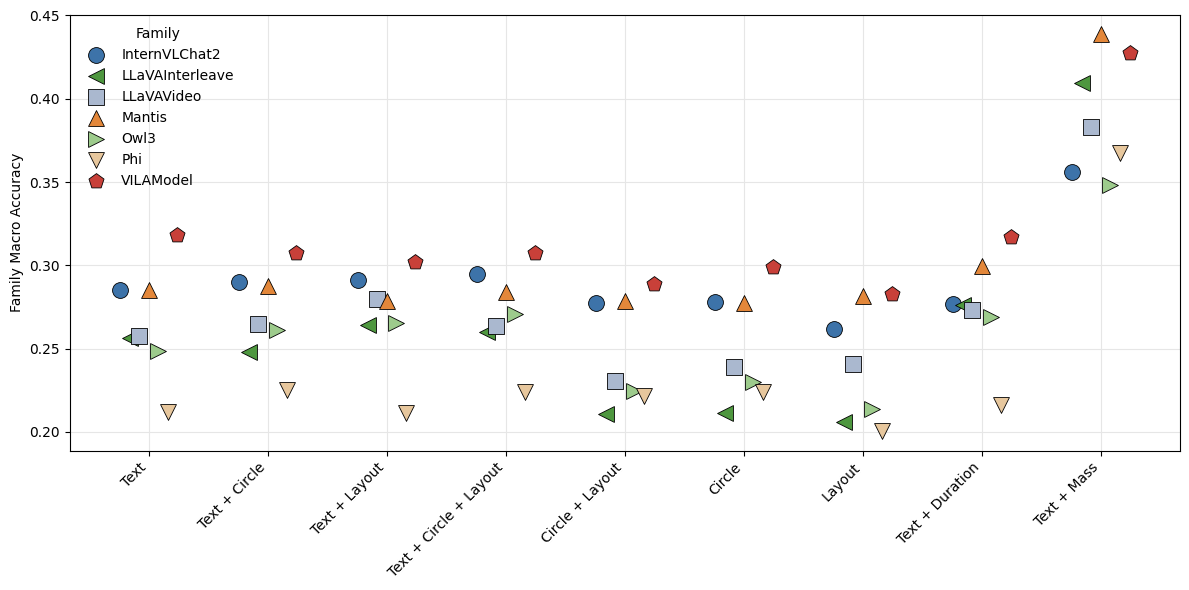

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1️⃣ Map run labels ---
macro_family["run_label"] = (
    macro_family["run_name"]
        .map(RUN_MAP)
        .fillna(macro_family["run_name"])
)

# --- 2️⃣ Preserve run order using RUN_INDEX ---
macro_family["run_index"] = macro_family["run_name"].map(RUN_INDEX)

macro_family = macro_family.sort_values("run_index")

RUN_ORDER = [RUN_MAP[r] for r in RUN_MAP.keys()]
x_positions = np.arange(len(RUN_ORDER))

# --- 3️⃣ Enforce family order ---
macro_family["family"] = pd.Categorical(
    macro_family["family"],
    categories=FAMILY_ORDER,
    ordered=True,
)

# --- 4️⃣ Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor(PLOT_BG)

n_fam = len(FAMILY_ORDER)
step = 0.08  # jitter spacing

for i, family in enumerate(FAMILY_ORDER):

    fam_df = (
        macro_family
            .loc[macro_family["family"] == family]
            .sort_values("run_index")
    )

    if fam_df.empty:
        continue

    y = fam_df["family_macro_accuracy"].values

    # centered jitter
    offset = (i - (n_fam - 1) / 2) * step

    ax.scatter(
        fam_df["run_index"].values + offset,
        y,
        label=family,
        marker=FAMILY_MARKERS.get(family, "o"),
        color=FAMILY_COLORS.get(family, "black"),
        s=130,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

# --- 5️⃣ Axis styling ---
ax.set_xticks(x_positions)
ax.set_xticklabels(RUN_ORDER, rotation=45, ha="right")

ax.set_ylabel("Family Macro Accuracy")

ax.grid(True, which="major", color=GRID_MAJOR, linewidth=0.8)
ax.grid(True, which="minor", color=GRID_MINOR, linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(frameon=False, title="Family")

plt.tight_layout()
plt.show()


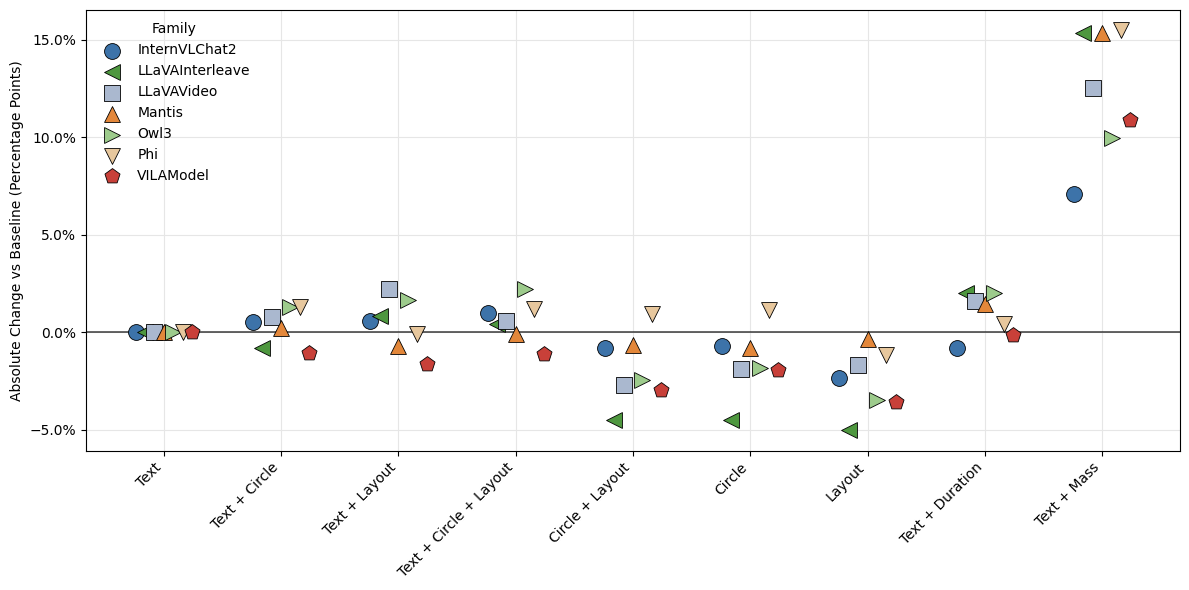

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick

# --------------------------------------------------
# 1️⃣ Identify baseline run (first in RUN_MAP)
# --------------------------------------------------

baseline_run = list(RUN_MAP.keys())[0]

# --------------------------------------------------
# 2️⃣ Extract baseline accuracy per family
# --------------------------------------------------

baseline_df = (
    macro_family
        .loc[macro_family["run_name"] == baseline_run]
        [["family", "family_macro_accuracy"]]
        .rename(columns={"family_macro_accuracy": "baseline_accuracy"})
)

# --------------------------------------------------
# 3️⃣ Merge baseline + compute absolute difference
# --------------------------------------------------

relative_df = macro_family.merge(
    baseline_df,
    on="family",
    how="left"
)

relative_df["absolute_change"] = (
    relative_df["family_macro_accuracy"]
    - relative_df["baseline_accuracy"]
)

# --------------------------------------------------
# 4️⃣ Preserve run order
# --------------------------------------------------

relative_df["run_index"] = relative_df["run_name"].map(RUN_INDEX)
relative_df = relative_df.sort_values("run_index")

RUN_ORDER = [RUN_MAP[r] for r in RUN_MAP.keys()]
x_positions = np.arange(len(RUN_ORDER))

# enforce family order
relative_df["family"] = pd.Categorical(
    relative_df["family"],
    categories=FAMILY_ORDER,
    ordered=True,
)

# --------------------------------------------------
# 5️⃣ Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor(PLOT_BG)

n_fam = len(FAMILY_ORDER)
step = 0.08  # jitter width

for i, family in enumerate(FAMILY_ORDER):

    fam_df = (
        relative_df
            .loc[relative_df["family"] == family]
            .sort_values("run_index")
    )

    if fam_df.empty:
        continue

    y = fam_df["absolute_change"].values

    # centered jitter
    offset = (i - (n_fam - 1) / 2) * step

    ax.scatter(
        fam_df["run_index"].values + offset,
        y,
        label=family,
        marker=FAMILY_MARKERS.get(family, "o"),
        color=FAMILY_COLORS.get(family, "black"),
        s=130,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

# zero reference line
ax.axhline(0, linewidth=1.2, color="black", alpha=0.7)

# axis formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(RUN_ORDER, rotation=45, ha="right")

ax.set_ylabel("Absolute Change vs Baseline (Percentage Points)")

# show as percentage points
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.grid(True, which="major", color=GRID_MAJOR, linewidth=0.8)
ax.grid(True, which="minor", color=GRID_MINOR, linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(frameon=False, title="Family")

plt.tight_layout()
plt.show()
